# DATA SCIENCE

# A. Load Data

### 1. Import library

In [1]:
!pip install split-folders -q

In [2]:
import os
import glob
import shutil
import pandas as pd
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import random
import matplotlib.pyplot as plt

### 2. Inisialisasi sumber dataset (data didapat dari kaggle lalu disimpan di github)

In [3]:
# --- Konfigurasi Global ---
REPO_URL = 'https://github.com/happy-ending-forever/capstone-tomato-leafguard.git'
REPO_DIR = '/content/capstone-tomato-leafguard'
OUTPUT_BASE = '/content/tomato_siap_training'
SEED = 28

In [4]:
# Melakukan git clone, jika folder sudah ada maka akan dilakukan git pull (Untuk kepentingan proses analisis)
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
    print("Download selesai!")
else:
    %cd {REPO_DIR}
    !git pull
    %cd /content
    print("Repository sudah diperbarui ke versi terbaru.")

# Mengarahkan path langsung ke folder 'dataset' di dalam repository
SOURCE_DIR = os.path.join(REPO_DIR, 'dataset')

print("\n Isi folder dataset:")
try:
    folder_contents = os.listdir(SOURCE_DIR)
    print(folder_contents)
    if len(folder_contents) == 0:
         print("Folder 'dataset' ditemukan, tapi isinya kosong.")
except FileNotFoundError:
    print(f"Error: Folder tidak ditemukan di {SOURCE_DIR}.")
    print("Pastikan kamu sudah melakukan commit dan push folder 'dataset' ke GitHub.")

Cloning into 'capstone-tomato-leafguard'...
remote: Enumerating objects: 18160, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 18160 (delta 0), reused 2 (delta 0), pack-reused 18158 (from 1)
Receiving objects: 100% (18160/18160), 272.02 MiB | 18.49 MiB/s, done.
Updating files: 100% (18160/18160), done.
Download selesai!

 Isi folder dataset:
['Tomato___Late_blight', 'Tomato___Bacterial_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Target_Spot', 'Tomato___Early_blight', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


# B. EDA

### 1. Melihat distribusi data tiap jenis penyakit

In [5]:
# Tampilan Dataset (frekuensi gambar berdasarkan penyakit)
data_info = []

if os.path.exists(SOURCE_DIR):
    for folder in sorted(os.listdir(SOURCE_DIR)):
        folder_path = os.path.join(SOURCE_DIR, folder)

        if os.path.isdir(folder_path) and not folder.startswith('.'):
            jumlah = len(os.listdir(folder_path))
            data_info.append({'Kategori Penyakit': folder, 'Jumlah Gambar': jumlah})

    df_info = pd.DataFrame(data_info)

    if not df_info.empty:
        total_gambar = df_info['Jumlah Gambar'].sum()
        print(f"Total keseluruhan gambar asli: {total_gambar}")
        print(f"Total jenis kategori: {len(df_info)}")
        print("-" * 35)
        print(df_info.to_string(index=False))
    else:
        print("Tidak ada folder kategori yang ditemukan di dalam SOURCE_DIR.")

Total keseluruhan gambar asli: 18160
Total jenis kategori: 10
-----------------------------------
                            Kategori Penyakit  Jumlah Gambar
                      Tomato___Bacterial_spot           2127
                        Tomato___Early_blight           1000
                         Tomato___Late_blight           1909
                           Tomato___Leaf_Mold            952
                  Tomato___Septoria_leaf_spot           1771
Tomato___Spider_mites Two-spotted_spider_mite           1676
                         Tomato___Target_Spot           1404
       Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
                 Tomato___Tomato_mosaic_virus            373
                             Tomato___healthy           1591


# C. Split Data

### 80 Training ; 20 Testing

In [6]:
# Hapus folder output jika sebelumnya sudah ada
if os.path.exists(OUTPUT_BASE):
    shutil.rmtree(OUTPUT_BASE)

# Memecah data dari SOURCE_DIR ke OUTPUT_BASE
splitfolders.ratio(SOURCE_DIR, output=OUTPUT_BASE, seed=SEED, ratio=(.8, .2), move=False)

TRAIN_DIR = os.path.join(OUTPUT_BASE, 'train')
VAL_DIR = os.path.join(OUTPUT_BASE, 'val')

print(f"Data berhasil dipisah dan diamankan ke: {OUTPUT_BASE}")

Copying files: 18160 files [00:03, 5033.39 files/s]

Data berhasil dipisah dan diamankan ke: /content/tomato_siap_training


# D. Feature Engineering (Augmentasi Gambar)

### Bertujuan untuk menyeimbangkan jumlah data tiap kategori penyakit.

In [7]:
# Augmentasi gambar (rotasi, flip, zoom, dll)
datagen = ImageDataGenerator(
    rotation_range=35,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.6, 1.4],
    channel_shift_range=50.0,
    fill_mode='nearest'
)

TARGET_COUNT = 1000 # Target hasil augmentasi agar frekuensi tiap penyakit seimbang sebanyak 1000

for kategori in os.listdir(TRAIN_DIR):
    kategori_path = os.path.join(TRAIN_DIR, kategori)
    if not os.path.isdir(kategori_path):
        continue

    gambar_saat_ini = glob.glob(os.path.join(kategori_path, '*.*'))
    jumlah_awal = len(gambar_saat_ini)

    print(f"\n[Proses] Kategori: {kategori} | Jumlah awal: {jumlah_awal}")

    if jumlah_awal == 0:
        continue

    # Undersampling jika data kelebihan
    if jumlah_awal > TARGET_COUNT:
        kelebihan = jumlah_awal - TARGET_COUNT
        print(f"  -> Mengurangi {kelebihan} gambar acak...")

        random.shuffle(gambar_saat_ini)
        for i in range(kelebihan):
            try:
                os.remove(gambar_saat_ini[i])
            except Exception:
                pass

    # Oversampling jika data kurang
    elif jumlah_awal < TARGET_COUNT:
        kekurangan = TARGET_COUNT - jumlah_awal
        print(f"  -> Menambah {kekurangan} gambar lewat augmentasi...")

        gambar_basis = glob.glob(os.path.join(kategori_path, '*.*'))
        jumlah_dibuat = 0

        while jumlah_dibuat < kekurangan:
            img_path = random.choice(gambar_basis)
            try:
                img = load_img(img_path)
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                for batch in datagen.flow(x, batch_size=1, save_to_dir=kategori_path, save_prefix='aug_bal', save_format='jpg'):
                    jumlah_dibuat += 1
                    break
            except Exception:
                continue

    else:
        print("  -> Data sudah pas 1000 gambar.")

    total_akhir = len(glob.glob(os.path.join(kategori_path, '*.*')))
    print(f"  -> Hasil Akhir Kategori {kategori}: {total_akhir} gambar.")

print("\n[SUKSES] Proses balancing data training selesai!")


[Proses] Kategori: Tomato___Late_blight | Jumlah awal: 1527
  -> Mengurangi 527 gambar acak...
  -> Hasil Akhir Kategori Tomato___Late_blight: 1000 gambar.

[Proses] Kategori: Tomato___Bacterial_spot | Jumlah awal: 1701
  -> Mengurangi 701 gambar acak...
  -> Hasil Akhir Kategori Tomato___Bacterial_spot: 1000 gambar.

[Proses] Kategori: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Jumlah awal: 4285
  -> Mengurangi 3285 gambar acak...
  -> Hasil Akhir Kategori Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 gambar.

[Proses] Kategori: Tomato___Spider_mites Two-spotted_spider_mite | Jumlah awal: 1340
  -> Mengurangi 340 gambar acak...
  -> Hasil Akhir Kategori Tomato___Spider_mites Two-spotted_spider_mite: 1000 gambar.

[Proses] Kategori: Tomato___Leaf_Mold | Jumlah awal: 761
  -> Menambah 239 gambar lewat augmentasi...
  -> Hasil Akhir Kategori Tomato___Leaf_Mold: 999 gambar.

[Proses] Kategori: Tomato___Septoria_leaf_spot | Jumlah awal: 1416
  -> Mengurangi 416 gambar acak...
  -> Hasil Akhi

### Contoh gambar hasil augmentasi.

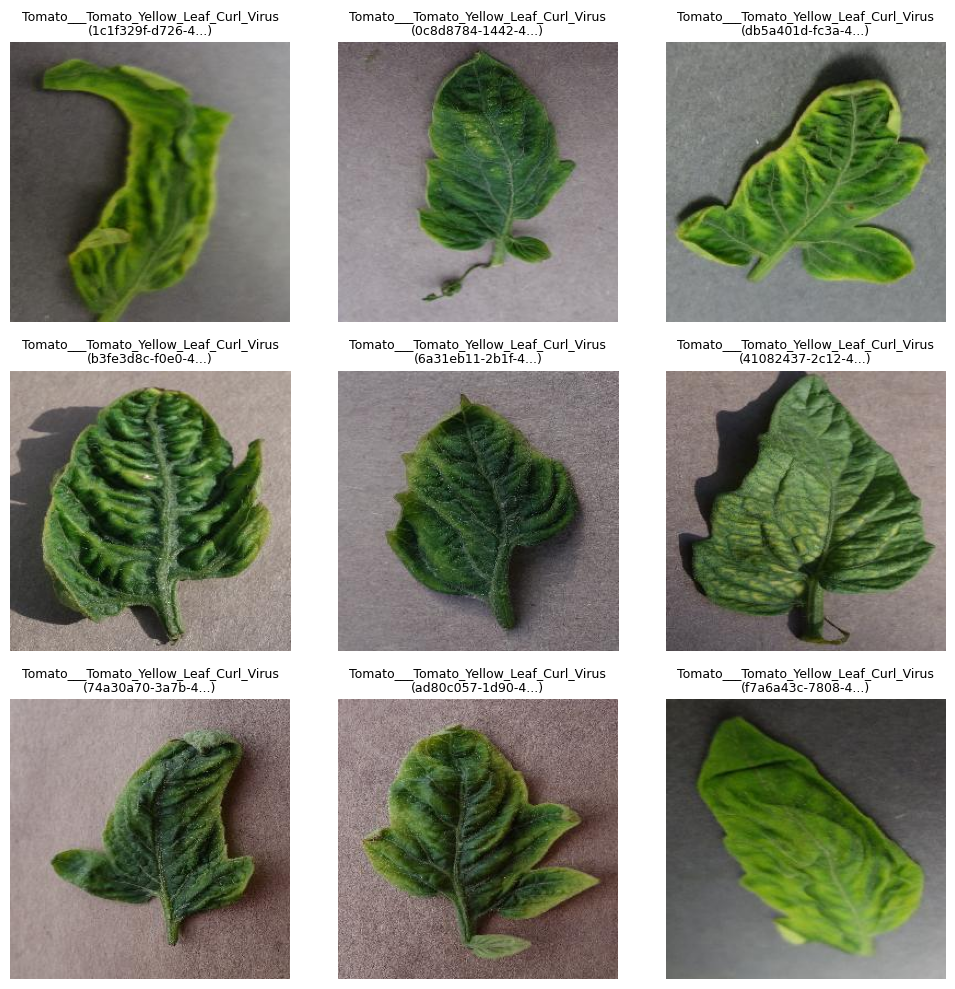

In [ ]:
# Preview gambar training
kategori_penyakit = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
kategori_acak = random.choice(kategori_penyakit)
kategori_path = os.path.join(TRAIN_DIR, kategori_acak)

# Mengambil semua file gambar
semua_gambar = [f for f in os.listdir(kategori_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if len(semua_gambar) >= 9:
    file_terpilih = random.sample(semua_gambar, 9)

    plt.figure(figsize=(10, 10))
    for i, file_name in enumerate(file_terpilih):
        img_path = os.path.join(kategori_path, file_name)
        img = load_img(img_path)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{kategori_acak}\n({file_name[:15]}...)", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Gambar di folder {kategori_acak} kurang dari 9 untuk ditampilkan.")

# AI ENGINEER

# 1. Import Library

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 2. Load Data

In [9]:
train_dir = '/content/tomato_siap_training/train'
val_dir = '/content/tomato_siap_training/val'

img_height, img_width, batch_size = 224, 224, 32

print("Membaca data gambar...")
train_data = tf.keras.utils.image_dataset_from_directory(
  train_dir, seed=123, image_size=(img_height, img_width), batch_size=batch_size)
val_data = tf.keras.utils.image_dataset_from_directory(
  val_dir, seed=123, image_size=(img_height, img_width), batch_size=batch_size)

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

Membaca data gambar...
Found 9971 files belonging to 10 classes.
Found 3637 files belonging to 10 classes.


# 3. Membangun Arsitektur dan Training Model (CNN)

In [10]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    # Arsitektur Terbalik (Bakal Underfitting)
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Mulai training Model...")
history = model.fit(train_data, validation_data=val_data, epochs=30, callbacks=[early_stop])

_, final_acc = model.evaluate(val_data, verbose=0)
print(f"\n=> AKURASI FINAL MODEL: {final_acc * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Mulai training Model...
Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.1679 - loss: 2.2493 - val_accuracy: 0.3429 - val_loss: 2.1666
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.2723 - loss: 1.9664 - val_accuracy: 0.4960 - val_loss: 1.6774
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.3527 - loss: 1.7006 - val_accuracy: 0.4726 - val_loss: 1.5701
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.4058 - loss: 1.5583 - val_accuracy: 0.5771 - val_loss: 1.3045
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4514 - loss: 1.4532 - val_accuracy: 0.6142 - val_loss: 1.1779
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.4851 - loss: 1.3600 - val_accuracy: 0.6841 - val_loss: 1.1569
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.5218 - loss: 1.3037 - val_accuracy: 0.6769 - val_loss: 1.1432
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 

# 4. Grafik Peforma Model

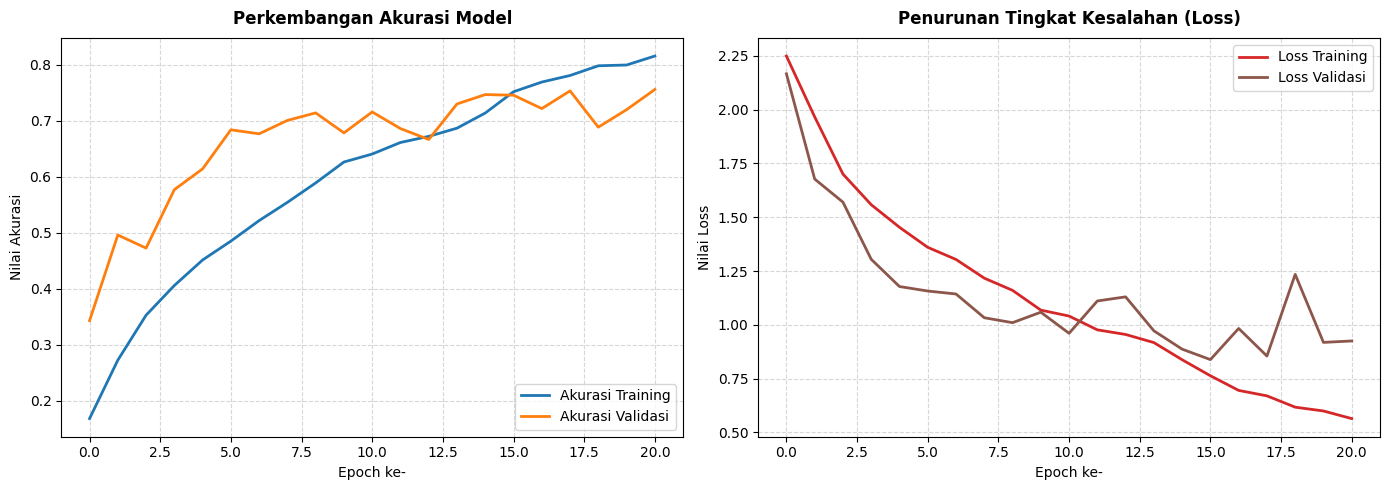

In [11]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# GRAFIK 1: AKURASI
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_acc, label='Akurasi Validasi', color='#ff7f0e', linewidth=2)
plt.title('Perkembangan Akurasi Model', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch ke-')
plt.ylabel('Nilai Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# GRAFIK 2: LOSS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training', color='#d62728', linewidth=2)
plt.plot(epochs_range, val_loss, label='Loss Validasi', color='#8c564b', linewidth=2)
plt.title('Penurunan Tingkat Kesalahan (Loss)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch ke-')
plt.ylabel('Nilai Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Kode Inference

Found 9971 files belonging to 10 classes.
Silakan masukkan foto daun tomat: 


Saving spider_mitejuga.jpg to spider_mitejuga.jpg

Berhasil mengupload file: "spider_mitejuga.jpg"

Memproses gambar...
Melakukan prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


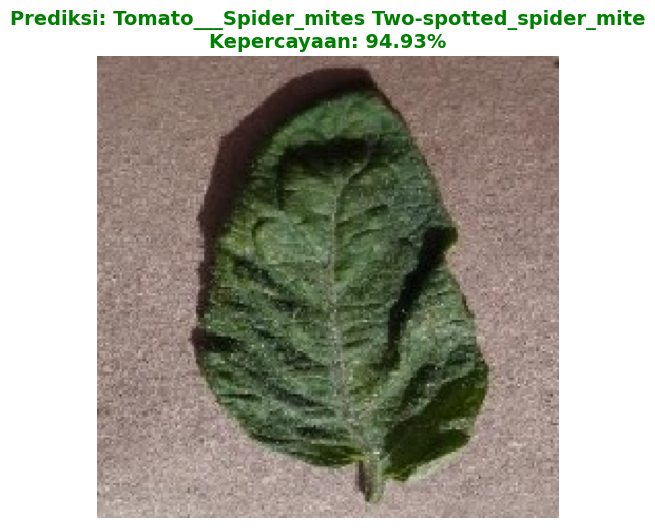


✨ HASIL PREDIKSI TOMATO LEAF-GUARDAI ✨
Penyakit terdeteksi : Tomato___Spider_mites Two-spotted_spider_mite
Tingkat Kepercayaan : 94.93%


In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

dataset_sementara = tf.keras.utils.image_dataset_from_directory(train_dir)
class_names = dataset_sementara.class_names

print("Silakan masukkan foto daun tomat: ")
uploaded = files.upload()

for fn in uploaded.keys():
    path_gambar_test = fn
    print(f'\nBerhasil mengupload file: "{fn}"')

print("\nMemproses gambar...")
img = image.load_img(path_gambar_test, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

print("Melakukan prediksi...")
predictions = model.predict(img_array)
score = predictions[0]

nama_prediksi = class_names[np.argmax(score)]
persentase = 100 * np.max(score)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediksi: {nama_prediksi}\nKepercayaan: {persentase:.2f}%", fontsize=14, fontweight='bold', color='green')
plt.show()

print("\n" + "="*45)
print("✨ HASIL PREDIKSI TOMATO LEAF-GUARDAI ✨")
print("="*45)
print(f"Penyakit terdeteksi : {nama_prediksi}")
print(f"Tingkat Kepercayaan : {persentase:.2f}%")
print("="*45)

# 6. Save Model

In [14]:
from google.colab import files

# menyimpan model di dalam folder temporary Google Colab
model.save('model_tomato_leaf_guardai.keras')
print("=> Model berhasil disimpan di Google Colab!")

# menyimpan model ke laptop
print("Memulai proses download ke laptop...")
files.download('model_tomato_leaf_guardai.keras')

=> Model berhasil disimpan di Google Colab!
Memulai proses download ke laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>